In [1]:
# Para manipulación y análisis de datos
!pip install pandas pymongo

# Para visualización de datos (gráficas)
!pip install matplotlib seaborn

# Opcional: Para análisis de sentimiento y lenguaje (muy cool para Andrés)
!pip install textblob

# Instalamos la versión CPU para ahorrar espacio
!pip install torch --index-url https://download.pytorch.org/whl/cpu
# Luego el resto
!pip install sentence-transformers scikit-learn scipy

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pymongo import MongoClient
import pandas as pd



## Obtención de datos
Se toman los datos obtenidos y guardados en la base de datos con el fin de iniciar el análisis

In [3]:
# Conexión al servicio de MongoDB
client = MongoClient('mongodb://mongodb:27017/')
db = client['social_analytics']
collections = db.list_collection_names()
print("🗄️ Colecciones encontradas en 'social_analytics':")
for c in collections:
    # Contamos cuántos documentos hay en cada una para darle más info a Andrés
    count = db[c].count_documents({})
    print(f" - {c} ({count} documentos)")



🗄️ Colecciones encontradas en 'social_analytics':
 - tweets (453 documentos)


In [4]:
collection = db['tweets']

# Convertir la colección a DataFrame
df = pd.DataFrame(list(collection.find()))

# Verificar si cargó algo
if df.empty:
    print("⚠️ El DataFrame está vacío. ¡Revisa si el Cron ya guardó algo!")
else:
    print(f"✅ Éxito: {len(df)} registros cargados en 'df'.")
    
# Ver qué columnas existen realmente
print("Columnas disponibles:", df.columns.tolist())

# Ver una muestra de los datos
display(df)

✅ Éxito: 453 registros cargados en 'df'.
Columnas disponibles: ['_id', 'tweet_id', 'account_label', 'author', 'content', 'timestamp_detected', 'timestamp_posted']


,_id,tweet_id,account_label,author,content,timestamp_detected,timestamp_posted
0,69d6d770d4b5be3196616259,2041660134846558664,Gamer_Project,@penikmat_hujann,What the fuck just happened?,2026-04-08T22:32:16.245440,2026-04-08T22:32:16.245427
1,69d6d770d4b5be319661625a,2041795685754818669,animecol300_Project,@KoruturkBey,"In Canada, a streamer nicknamed Joker was raid...",2026-04-09T01:57:32.298134,2026-04-09T01:57:32.298121
2,69d6d770d4b5be319661625b,2041802128994275586,animecol300_Project,@Kaliza_queen,This video say a lot about nowadays society......,2026-04-09T01:33:32.256519,2026-04-09T01:33:32.256505
3,69d6d770d4b5be319661625c,analytics,animecol300_Project,@rogueducknet,Make the perfect stew in our witch-themed deck...,2026-04-09T03:21:42.989870,2026-04-09T03:21:42.989854
4,69d6d770d4b5be319661625d,2041954231817769138,Gamer_Project,@TheNetDaily,Jake Paul Got Caught,2026-04-08T22:51:53.851682,2026-04-08T22:51:53.851668
...,...,...,...,...,...,...,...
448,69d71ac6d68eedba1b9004e3,2041622041695285449,marthasteward295,@bts_bighit,[Notice] BTS (Bangtan Sonyeondan) WORLD TOUR ‘...,2026-04-09T03:19:34.136540,2026-04-09T03:19:34.136525
449,69d71ac6d68eedba1b9004e4,2041810576142405682,marthasteward295,@TheePopCore,Former ENHYPEN member Heeseung is set to redeb...,2026-04-09T03:19:34.279050,2026-04-09T03:19:34.279037
450,69d71b28d68eedba1b9004e5,2042053520090640790,Gamer_Project,@twibuznewss,A man who wore himself out to help a dog,2026-04-09T03:21:22.574862,2026-04-09T03:21:22.574849
451,69d71b5cd68eedba1b9004e6,2042052397489672304,marthasteward295,@narendramodi,Calling upon the people of Keralam to vote in ...,2026-04-09T03:22:04.453179,2026-04-09T03:22:04.453166


Se hace una exploración inicial de los datos para identificar cuales son las cuentas de las que más se reciben tweets, se evidencia que a pesar de que ninguna cuenta sigue a @elonmusk se ve que las cuentas reciben tweets de él.

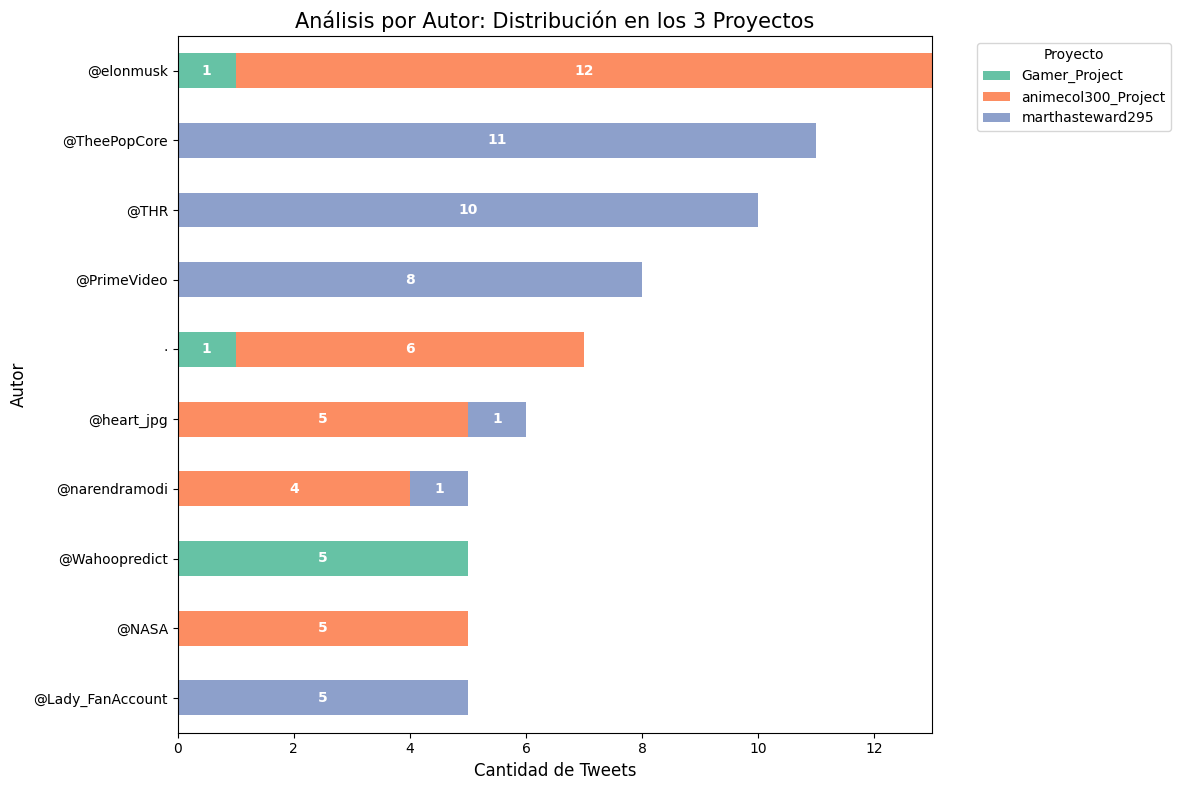

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los Top 10 autores
top_10_names = df['author'].value_counts().head(10).index
df_top = df[df['author'].isin(top_10_names)]

# 2. Creamos el pivot
pivot_df = df_top.groupby(['author', 'account_label']).size().unstack(fill_value=0)

# 3. Ordenar por total
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('total', ascending=True).drop(columns='total')

# --- MEJORA AQUÍ: Colores dinámicos ---
# Generamos una paleta de colores profesional (Set2, Viridis o Flare) 
# que tenga exactamente el número de colores que proyectos hay
num_proyectos = len(pivot_df.columns)
colores_proyecto = sns.color_palette("Set2", num_proyectos)

# 4. Graficamos con la nueva paleta
ax = pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), color=colores_proyecto)

# Añadimos los números dentro de las barras para que Andrés lo explique mejor
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{int(width)}', ha='center', va='center', color='white', fontweight='bold')

plt.title('Análisis por Autor: Distribución en los 3 Proyectos', fontsize=15)
plt.xlabel('Cantidad de Tweets', fontsize=12)
plt.ylabel('Autor', fontsize=12)
plt.legend(title='Proyecto', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

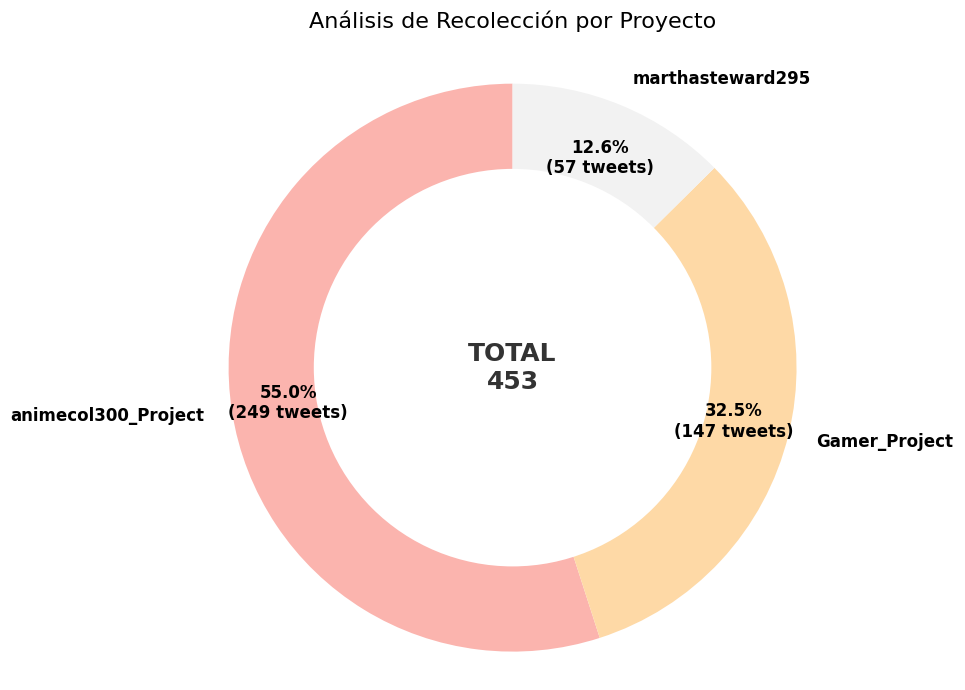

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
conteo = df['account_label'].value_counts()
total_tweets = conteo.sum()

# 2. Generar los colores manualmente (solución al error TypeError)
# Usamos el mapa de colores 'Pastel1' basado en la cantidad de categorías que tengamos
colores = plt.get_cmap('Pastel1')(np.linspace(0, 1, len(conteo)))

# 3. Función para mostrar porcentaje y cantidad
def fmt_cantidad(pct):
    absolute = int(round(pct/100.*total_tweets))
    return f"{pct:.1f}%\n({absolute} tweets)"

plt.figure(figsize=(10, 7))

# 4. Dibujar la torta (ahora usamos 'colors' en lugar de 'cmap')
plt.pie(conteo, labels=conteo.index, autopct=fmt_cantidad, 
        startangle=90, colors=colores, pctdistance=0.80,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 5. Dibujar el círculo blanco central para que sea una DONA
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

# 6. Poner el gran TOTAL en el centro de la dona
plt.text(0, 0, f'TOTAL\n{total_tweets}', ha='center', va='center', 
         fontsize=18, fontweight='bold', color='#333333')

plt.title('Análisis de Recolección por Proyecto', fontsize=16, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()

## Procesamiento de texto a vectores (Embeddings)
Convertir el contenido de los tweets en números.


In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Cargamos el modelo (el mismo que citaron en su artículo)
model = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Tomamos los textos de nuestra base de datos (df['content'])
textos = df['content'].fillna("").tolist()

# 3. ¡MAGIA! Convertimos los 164 tweets en vectores
# Cada tweet ahora es una lista de 384 números
embeddings = model.encode(textos)

print(f"✅ Hemos convertido {len(embeddings)} tweets en vectores de dimensión {embeddings.shape[1]}")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5210.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Hemos convertido 453 tweets en vectores de dimensión 384


In [8]:
print(embeddings)

[[-0.05179118  0.00033369  0.0511012  ... -0.00082497  0.05301495
   0.01868276]
 [-0.06202882  0.00303204 -0.06478949 ...  0.05405934 -0.01374433
   0.0125442 ]
 [-0.04360653 -0.01821359 -0.10178803 ... -0.01710293  0.11621358
  -0.02902644]
 ...
 [-0.04269379  0.10281727  0.01392477 ... -0.01466876  0.04850334
   0.02175285]
 [ 0.04888216 -0.00021547 -0.01349059 ... -0.02583456 -0.04817517
  -0.04658023]
 [-0.00975685  0.01882842 -0.04429106 ... -0.08622608 -0.03871583
   0.04943865]]


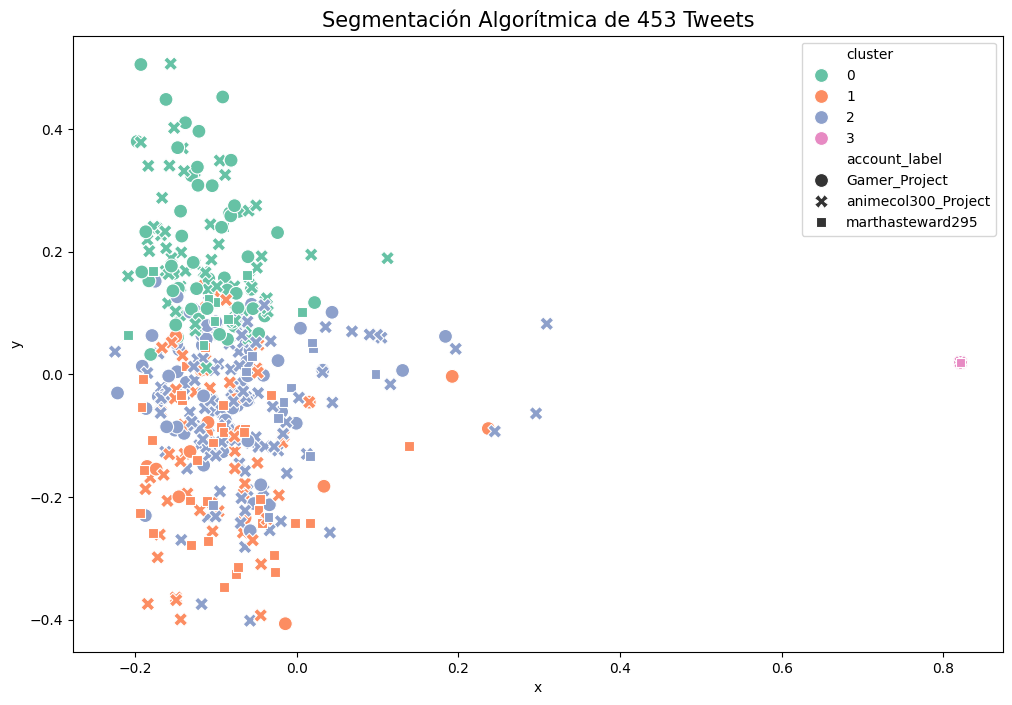

In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear 4 grupos (clusters) basados en los vectores
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(embeddings)

# 2. Reducir a 2D para poder graficar (PCA)
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
df['x'] = coords[:, 0]
df['y'] = coords[:, 1]

# 3. Graficar
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='x', y='y', hue='cluster', style='account_label', palette='Set2', s=100)
plt.title(f'Segmentación Algorítmica de {len(df)} Tweets', fontsize=15)
plt.show()